# 3.3 Ejercicios: Redes libres de escala y distribuciones de grado

Ana Luisa Llamas Martinez

ENES-Juriquilla

In [352]:
import matplotlib.pyplot as plt
import random
from scipy.stats import binom, poisson
import numpy as np
import math

np.random.seed(42)
random.seed(42)


def distribucion_grado(grados):
    k, conteos = np.unique(grados, return_counts=True)
    pk = conteos / len(grados)
    return k, pk

## Ejercicio 1. Comparación de distribuciones

Genera dos conjuntos de datos de tamaño grande (por ejemplo, $N=10^{4}$):
- Uno que siga una distribución de Poisson.
- Otro que siga una distribución de ley de potencia con exponente γ.

Calcula la distribución de grado $p_k$ en ambos casos.

**Tareas:**
- Grafica ambas distribuciones en escala lineal.
- Grafícalas en escala log-log.
- Compara visualmente ambas gráficas.

In [353]:
N1 = 10000

poisson1 = np.random.poisson(lam=10, size=N1)
leypot1 = np.random.zipf(a=2.01, size = N1)

In [354]:
#distribuciones

distgpoisson1 = distribucion_grado(poisson1)
distgleypot1 = distribucion_grado(leypot1)

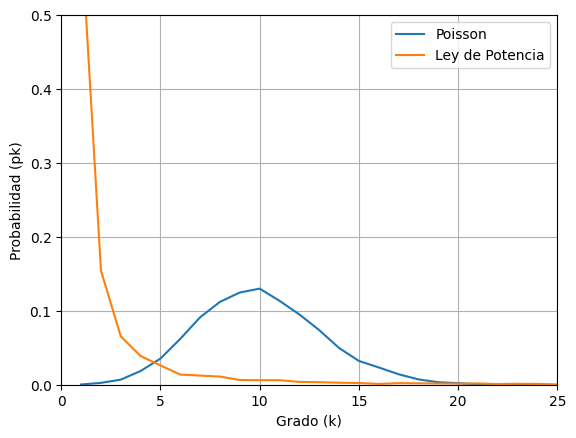

In [355]:
plt.plot(distgpoisson1[0], distgpoisson1[1], label='Poisson')
plt.plot(distgleypot1[0], distgleypot1[1], label='Ley de Potencia')
plt.xlabel('Grado (k)')
plt.ylabel('Probabilidad (pk)')
plt.xlim(0, 25)
plt.ylim(0, 0.5)
plt.legend()
plt.grid(True)
plt.show()

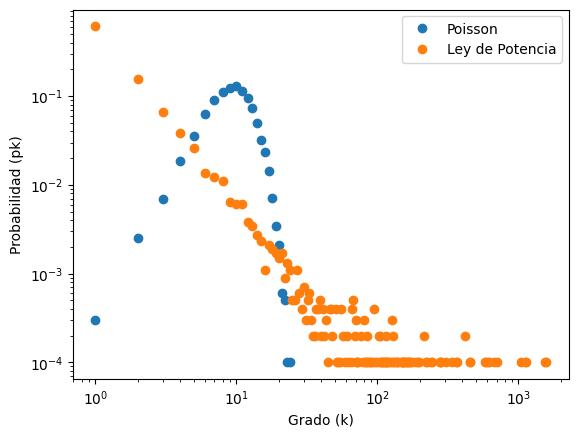

In [356]:
plt.loglog(distgpoisson1[0], distgpoisson1[1], 'o', label='Poisson')
plt.loglog(distgleypot1[0], distgleypot1[1], 'o', label='Ley de Potencia')
plt.xlabel('Grado (k)')
plt.ylabel('Probabilidad (pk)')
plt.legend()
plt.show()

In [357]:
"""
log_bins = np.geomspace(leypot1.min(), leypot1.max(), num=30)

plt.hist(poisson1, bins=log_bins, density=True, color='royalblue')
plt.hist(leypot1, bins=log_bins, density=True, alpha=0.6, 
         color='red', edgecolor='darkred', linewidth=1.2)
plt.xlabel('Grado (k)')
plt.ylabel('Probabilidad (pk)')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

"""


"\nlog_bins = np.geomspace(leypot1.min(), leypot1.max(), num=30)\n\nplt.hist(poisson1, bins=log_bins, density=True, color='royalblue')\nplt.hist(leypot1, bins=log_bins, density=True, alpha=0.6, \n         color='red', edgecolor='darkred', linewidth=1.2)\nplt.xlabel('Grado (k)')\nplt.ylabel('Probabilidad (pk)')\nplt.xscale('log')\nplt.yscale('log')\nplt.legend()\nplt.show()\n\n"

**Preguntas:**

- ¿Qué diferencias observas entre ambas distribuciones?

    **R=** La distribución Poisson sigue una distribución normal, mientras que la distribución de ley de potencia solo decae.

- ¿En cuál aparecen nodos con grados muy grandes (hubs)?

    **R=** En la distribución de ley de potencia.

## Ejercicio 2. Efecto de la escala log-log.

Usando una muestra con distribución de ley de potencia:

**Tareas:**
- Grafica la distribución de grado en escala lineal.
- Grafícala en escala log-log.

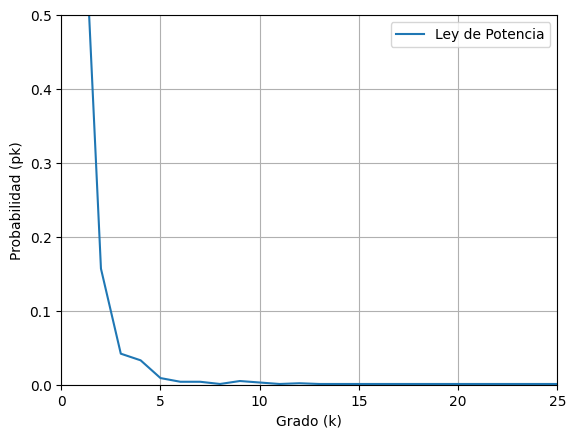

In [358]:
N2 = 1000

leypot2 = np.random.zipf(a=2.5, size = N2)

distgleypot2 = distribucion_grado(leypot2)

plt.plot(distgleypot2[0], distgleypot2[1], label='Ley de Potencia')
plt.xlabel('Grado (k)')
plt.ylabel('Probabilidad (pk)')
plt.xlim(0, 25)
plt.ylim(0, 0.5)
plt.legend()
plt.grid(True)
plt.show()

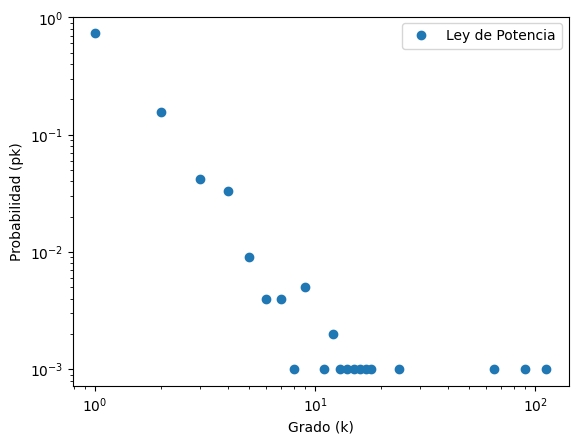

In [359]:
plt.loglog(distgleypot2[0], distgleypot2[1], 'o', label='Ley de Potencia')
plt.xlabel('Grado (k)')
plt.ylabel('Probabilidad (pk)')
plt.legend()
plt.show()

**Preguntas:**
- ¿Qué información se pierde en la escala lineal?

    **R=** Perdemos información sobre la existencia de hubs y el detalle de la cola. En este caso, no es pesada.

- ¿Por qué la gráfica log-log permite observar mejor la cola de la distribución?

    **R=** Porque pasa a a ser una relación lineal, lo que permite la identificación más fácil de una recta.

## Ejercicio 3. Linear binning vs log-binning

Genera un conjunto de grados con distribución de ley de potencia.

**Tareas:**
- Construye un histograma usando bins lineales.
- Construye un histograma usando bins logarítmicos.
- Grafica ambos en escala log-log.

Text(0, 0.5, 'Probabilidad p(k)')

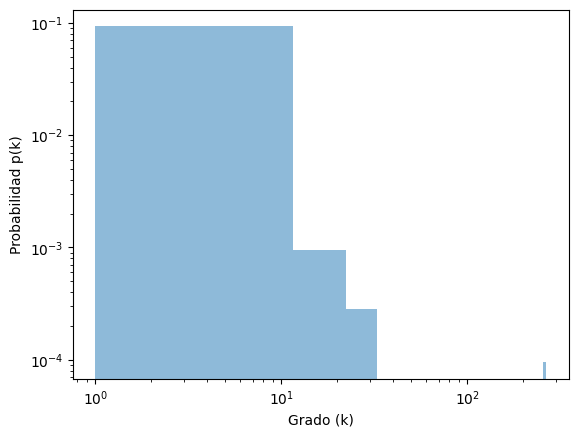

In [360]:
N3 = 1000

leypot2 = np.random.zipf(a=2.5, size = N3)

bins_lin3 = 25
bins_log3 = np.geomspace(leypot2.min(), leypot2.max(), num=25)

plt.hist(leypot2, bins=bins_lin3, density=True, alpha=0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Grado (k)')
plt.ylabel('Probabilidad p(k)')

Text(0, 0.5, 'Probabilidad p(k)')

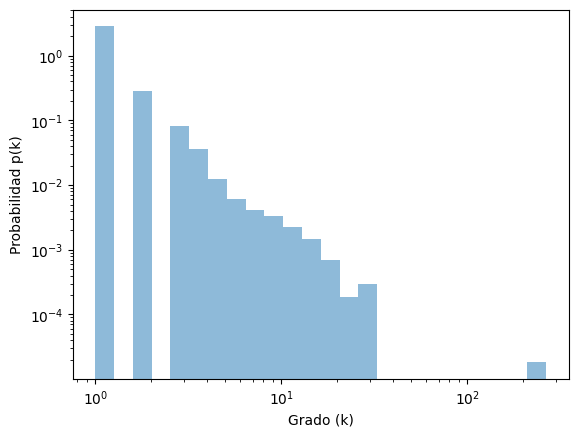

In [361]:
plt.hist(leypot2, bins=bins_log3, density=True, alpha=0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Grado (k)')
plt.ylabel('Probabilidad p(k)')

**Preguntas:**
- ¿Aparece una meseta en la cola con bins lineales?

    **R=** Sí, en las últimas dos barras.

- ¿Qué cambia al usar bins logarítmicos?

    **R=** Desaparece la meseta.

- ¿Cuál método representa mejor la distribución?

    **R=** La gráfica log-log.

## Ejercicio 4. Distribución acumulada

Dada una muestra de grados con ley de potencia:

**Tareas:**
- Calcula la distribución acumulada complementaria:
$$ P(k) = P(K \geq k) $$

- Grafícala en escala log-log.

C:\Users\analu\AppData\Local\Temp\ipykernel_17220\4132785453.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


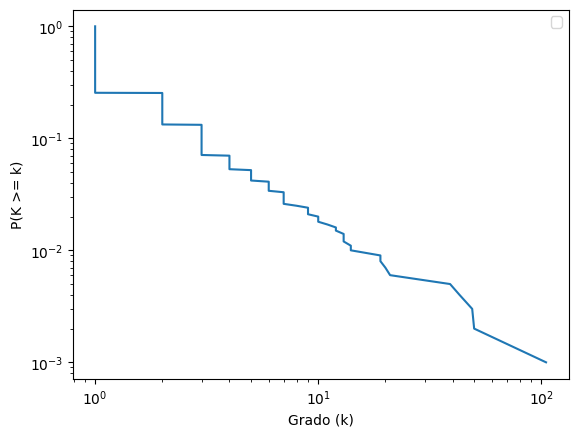

In [362]:
N4 = 1000

leypot4 = np.random.zipf(a=2.5, size = N4)

#P(K >= k) = 1 - P(K<k)

lista_ordenada = np.sort(leypot4)

p_cumulada = 1.0 - (np.arange(len(lista_ordenada)) / len(lista_ordenada))

plt.loglog(lista_ordenada, p_cumulada)
plt.xlabel('Grado (k)')
plt.ylabel('P(K >= k)')
plt.legend()
plt.show()

C:\Users\analu\AppData\Local\Temp\ipykernel_17220\3566981552.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


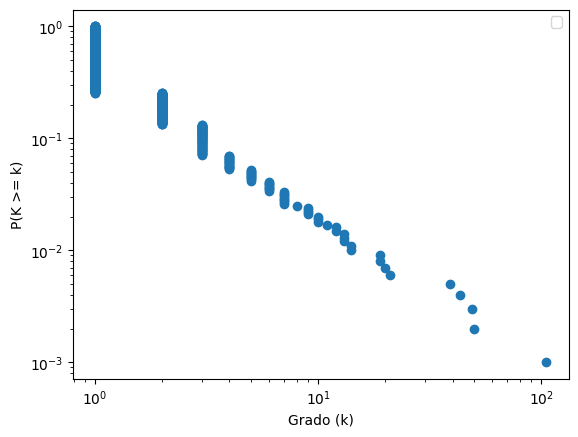

In [363]:
plt.loglog(lista_ordenada, p_cumulada, 'o')
plt.xlabel('Grado (k)')
plt.ylabel('P(K >= k)')
plt.legend()
plt.show()

**Preguntas:**
- ¿Qué ventaja tiene la distribución acumulada respecto al histograma?

**R=** No se necesitaron bins, además que es más fácil observar una recta.

- ¿Qué sucede con el ruido en la cola?

**R=** No hay mesetas.


## Ejercicio 5. El papel del exponente $\gamma$
 

Genera distribuciones de ley de potencia con distintos valores de $\gamma$, por ejemplo:
$$\gamma = 2.1, 2.5, 3.0, 4.0$$

**Tareas:**
- Grafica todas las distribuciones en escala log-log.

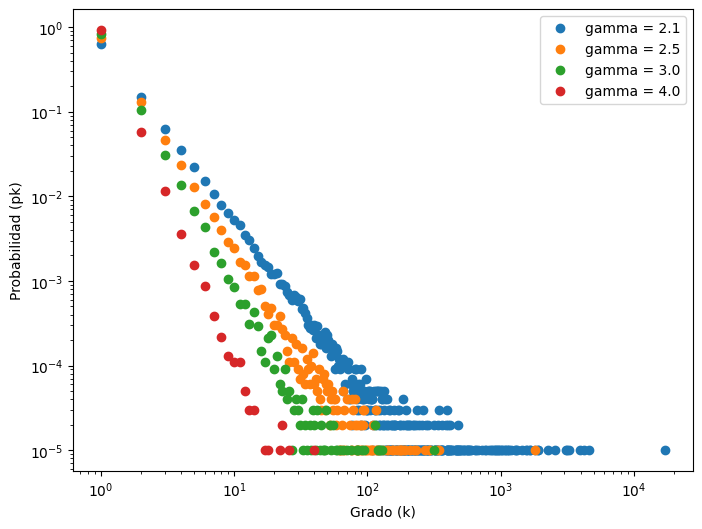

In [364]:
N5 = 100000
gamma = [2.1, 2.5, 3.0, 4.0]

plt.figure(figsize=(8, 6))

for i in gamma:
    leypot = np.random.zipf(a=i, size = N5)

    distgleypot = distribucion_grado(leypot)

    plt.loglog(distgleypot[0], distgleypot[1], 'o', label=f'gamma = {i}')


plt.xlabel('Grado (k)')
plt.ylabel('Probabilidad (pk)')
plt.legend()
plt.show()
    

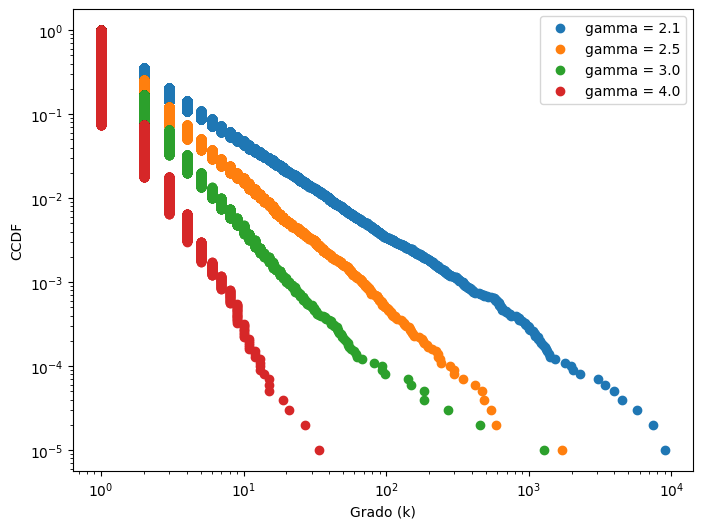

In [365]:
plt.figure(figsize=(8, 6))

for i in gamma:
    leypot = np.random.zipf(a=i, size = N5)

    lista_ordenada = np.sort(leypot)

    p_cumulada = 1.0 - (np.arange(len(lista_ordenada)) / len(lista_ordenada))

    plt.loglog(lista_ordenada, p_cumulada, 'o', label=f'gamma = {i}')


plt.xlabel('Grado (k)')
plt.ylabel('CCDF')
plt.legend()
plt.show()

**Preguntas:**
- ¿Cómo cambia la forma de la distribución al variar $\gamma$?

    **R=** Entre más crece gamma, la pendiente empieza a pronunciarse más.

- ¿Para qué valores aparecen hubs más grandes?

    **R=** Con valores de gamma pequeños.

- ¿Cuándo la distribución empieza a parecerse a una red aleatoria?

    **R=** Cuando gamma es igual o mayor a tres, puesto que las colas de las distribuciones dejan de ser pesadas.

## Ejercicio 6. Tamaño de la red y hubs

Para distintos tamaños de red:
$$N = 10^{2}, 10^{3}, 10^{4}, 10^{5}$$

genera muestras con distribución de ley de potencia.

**Tareas:**
- Para cada N, calcula el grado máximo $k_{max}$.
- Grafica $k_{max}$ como función de N.

C:\Users\analu\AppData\Local\Temp\ipykernel_17220\2450808911.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


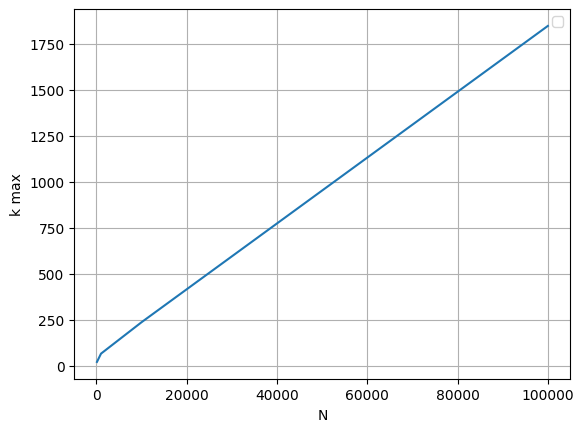

In [380]:
gamma = 2.66

N = [10**2, 10**3, 10**4, 10**5]
Kmax=[]
    
for i in N:
    leypot = np.random.zipf(a=gamma, size = i)
    kmax = max(leypot)

    Kmax.append(kmax)

plt.plot(N, Kmax)
plt.xlabel('N')
plt.ylabel('k max')
plt.legend()
plt.grid(True)
plt.show()

**Preguntas:**
- ¿Cómo crece el hub más grande con el tamaño de la red?

    **R=** Crecen de manera similar/proporcional.

- ¿Es el crecimiento rápido o lento?

    **R=** Es rápido.

## Ejercicio 7. Redes aleatorias vs redes libres de escala

Genera dos redes con el mismo número de nodos:
- Una red de Erdős–Rényi.
- Una red de Barabási–Albert, esto simula la red libre de escala.

**Tareas:**
- Calcula la distribución de grado en ambas redes.
- Grafícalas en escala log-log.
- Calcula:
    - grado promedio
    - grado máximo

In [389]:
import networkx as nx

N7 = 500

E = nx.erdos_renyi_graph(n=N7,p=0.02, seed=42)
B = nx.barabasi_albert_graph(n=N7, m=5, seed=42)

In [390]:
distgradE = distribucion_grado(list(dict(E.degree()).values()))
distgradB = distribucion_grado(list(dict(B.degree()).values()))


print(f"El grado promedio de la red Erdos es {np.mean(list(dict(E.degree()).values()))}, mientras que el grado máximo, {max(dict(E.degree()).values())}")
print(f"El grado promedio de la red Barbási es {np.mean(list(dict(B.degree()).values()))}, mientras que el grado máximo, {max(dict(B.degree()).values())}")

El grado promedio de la red Erdos es 9.748, mientras que el grado máximo, 19
El grado promedio de la red Barbási es 9.9, mientras que el grado máximo, 102


C:\Users\analu\AppData\Local\Temp\ipykernel_17220\4073649956.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


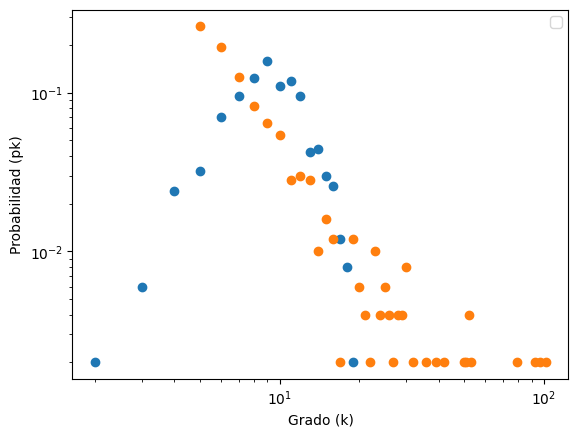

In [391]:
plt.loglog(distgradE[0], distgradE[1], 'o')
plt.loglog(distgradB[0], distgradB[1], 'o')
plt.xlabel('Grado (k)')
plt.ylabel('Probabilidad (pk)')
plt.legend()
plt.show()

C:\Users\analu\AppData\Local\Temp\ipykernel_17220\2147701937.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


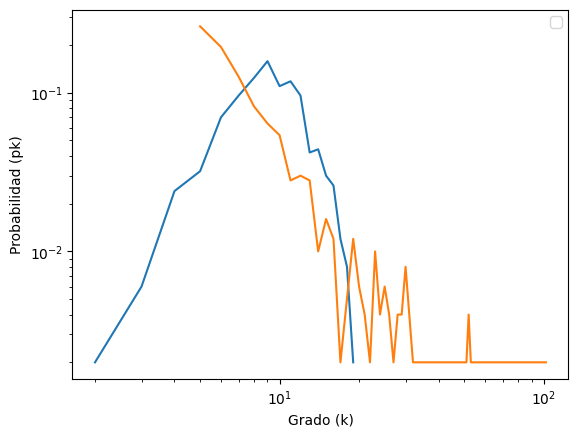

In [392]:
plt.loglog(distgradE[0], distgradE[1])
plt.loglog(distgradB[0], distgradB[1])
plt.xlabel('Grado (k)')
plt.ylabel('Probabilidad (pk)')
plt.legend()
plt.show()

**Preguntas:**
- ¿En cuál red aparecen hubs?

    **R=** En la red de Barabási–Albert

- ¿En cuál red los grados son más homogéneos?

    **R=** red de Erdős–Rényi.

## Ejercicio 8. Distancias en redes

Usando las redes del ejercicio anterior:

**Tareas:**
- Calcula la distancia promedio entre nodos (en la componente gigante si es necesario).

In [393]:
nx.is_connected(E)

True

In [394]:
nx.is_connected(B)

True

In [395]:
print("La distancia promedio entre nodos de la red Erdos es :", nx.average_shortest_path_length(E))
print("La distancia promedio entre nodos de la red Barbasi es :", nx.average_shortest_path_length(B))

La distancia promedio entre nodos de la red Erdos es : 2.9674468937875753
La distancia promedio entre nodos de la red Barbasi es : 2.7308456913827657


**Preguntas:**
- ¿Cuál red tiene menor distancia promedio?

    **R=** La red de Barabási–Albert

- ¿Cómo se relaciona esto con la presencia de hubs?

    **R=** En una red libre de escala hay presencia de hubs, lo que facilita llegar de un nodo A a un nodo B.

## Ejercicio 9. Robustez de la red

Considera una red libre de escala.

**Tareas:**
- Elimina nodos de forma aleatoria y mide el tamaño de la componente gigante.
- Elimina nodos en orden decreciente de grado (primero los hubs).
- Compara ambos casos.

In [375]:
import random

G = nx.barabasi_albert_graph(n=25, m=4, seed=42)

nodos_random = random.sample(range(1, 1001), 25)
nodos_decrecientes =  sorted(dict(G.degree()), key=dict(G.degree()).get)[1]

nodos_decrecientes

1

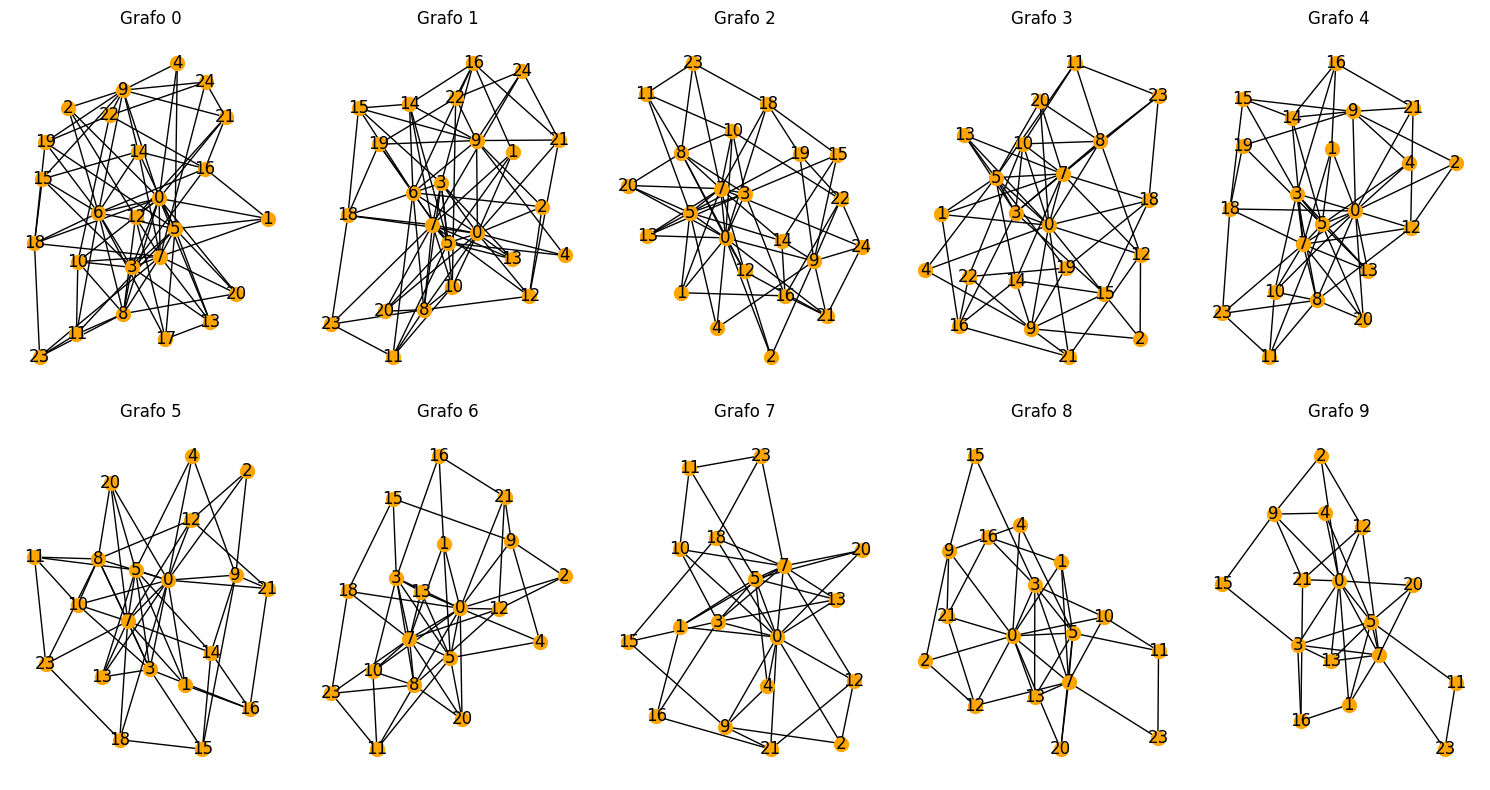

In [376]:
G1 = G.copy()

fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.flatten()

for i in range(0,10):
    nx.draw(G1, ax=axes[i], with_labels=True, node_size=100, node_color='orange')
    axes[i].set_title(f"Grafo {i}")

    nodos = list(G1.nodes())
    nodo = random.choice(nodos)
    G1.remove_node(nodo)

plt.tight_layout()
plt.show()

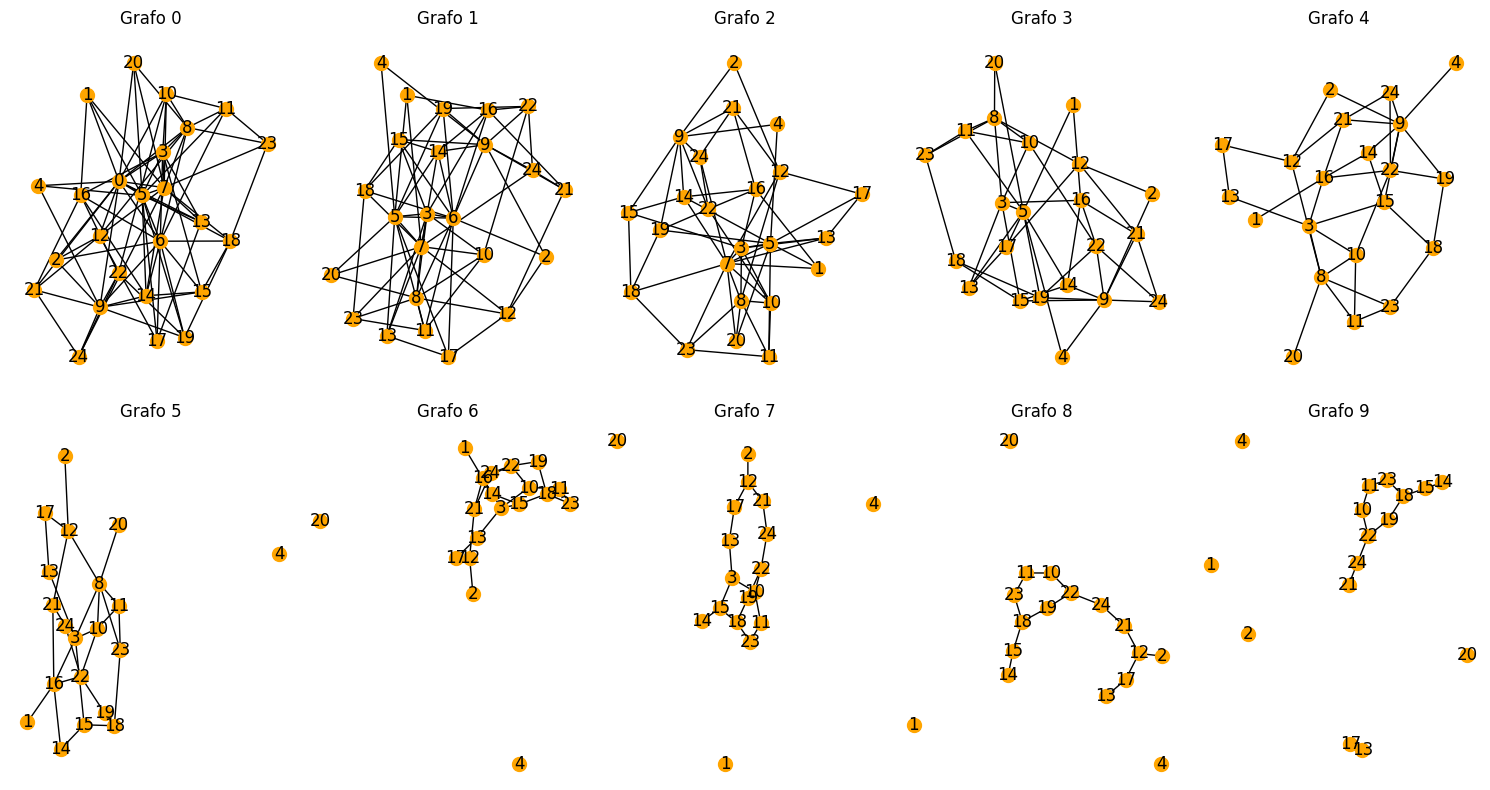

In [377]:
G2 = G.copy()
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.flatten()

for i in range(0,10):
    nx.draw(G2, ax=axes[i], with_labels=True, node_size=100, node_color='orange')
    axes[i].set_title(f"Grafo {i}")

    nodo = max(dict(G2.degree()), key=dict(G2.degree()).get)
    G2.remove_node(nodo)

plt.tight_layout()
plt.show()

**Preguntas:**
- ¿Qué tipo de eliminación afecta más a la red?

    **R=** Eliminando nodos en orden decreciente de grado.

- ¿Qué nos dice esto sobre la importancia de los hubs?

    **R=** Son puntos críticos para la conexidad de la red.

## Ejercicio 10. Análisis de una red real o simulada

Selecciona una red (real o generada).

**Tareas:**
- Calcula su distribución de grado.
- Grafícala en escala log-log.
- Decide si:
    - es exponencialmente acotada, o
    - tiene cola pesada.


C:\Users\analu\AppData\Local\Temp\ipykernel_17220\1215144776.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


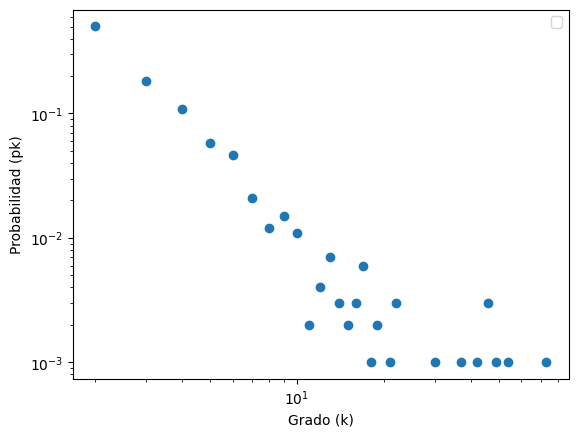

In [378]:
G10 = nx.barabasi_albert_graph(n=1000, m=2)

grados10 = list(dict(G10.degree()).values())

distgrad10 = distribucion_grado(grados10)

plt.loglog(distgrad10[0], distgrad10[1], 'o')
plt.xlabel('Grado (k)')
plt.ylabel('Probabilidad (pk)')
plt.legend()
plt.show()

In [379]:
"""
M = nx.les_miserables_graph()

gradosM = list(dict(M.degree()).values())

distgradM = distribucion_grado(gradosM)

plt.loglog(distgradM[0], distgradM[1], 'o')
plt.xlabel('Grado (k)')
plt.ylabel('Probabilidad (pk)')
plt.legend()
plt.show()
"""

"\nM = nx.les_miserables_graph()\n\ngradosM = list(dict(M.degree()).values())\n\ndistgradM = distribucion_grado(gradosM)\n\nplt.loglog(distgradM[0], distgradM[1], 'o')\nplt.xlabel('Grado (k)')\nplt.ylabel('Probabilidad (pk)')\nplt.legend()\nplt.show()\n"

**Preguntas:**
- ¿Hay evidencia de hubs?

    **R=** Sí, podemos apreciar puntos extremos en la derecha.

- ¿El promedio describe bien a la red?

    **R=** No, dado que podemos observar una cola pesada.